In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv("E:\\stocks.csv")

df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [4]:
#DATA EXPLORATION

print("\nShape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


Shape: (248, 8)

First 5 Rows:
  Ticker        Date        Open        High         Low       Close  \
0   AAPL  2023-02-07  150.639999  155.229996  150.639999  154.649994   
1   AAPL  2023-02-08  153.880005  154.580002  151.169998  151.919998   
2   AAPL  2023-02-09  153.779999  154.330002  150.419998  150.869995   
3   AAPL  2023-02-10  149.460007  151.339996  149.220001  151.009995   
4   AAPL  2023-02-13  150.949997  154.259995  150.919998  153.850006   

    Adj Close    Volume  
0  154.414230  83322600  
1  151.688400  64120100  
2  150.639999  56007100  
3  151.009995  57450700  
4  153.850006  62199000  

Missing Values:
Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Data Types:
Ticker        object
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [6]:
#DATA CLEANING

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df.ffill(inplace=True)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop invalid dates
df = df.dropna(subset=['Date'])

# Sort data
df = df.sort_values(by=['Ticker', 'Date'])

In [7]:
# FEATURE ENGINEERING

# Daily Return
df['Daily Return'] = df.groupby('Ticker')['Close'].pct_change()

# Moving Averages
df['MA_7'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(7).mean())
df['MA_30'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(30).mean())

# Extract Month & Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [8]:
# DATA ANALYSIS

# Select one stock (example: first ticker)
stock = df['Ticker'].iloc[0]
stock_df = df[df['Ticker'] == stock]

print(f"\nAnalyzing Stock: {stock}")

# Trend
price_trend = stock_df.set_index('Date')['Close']

# Monthly average
monthly_avg = stock_df.groupby('Month')['Close'].mean()



Analyzing Stock: AAPL


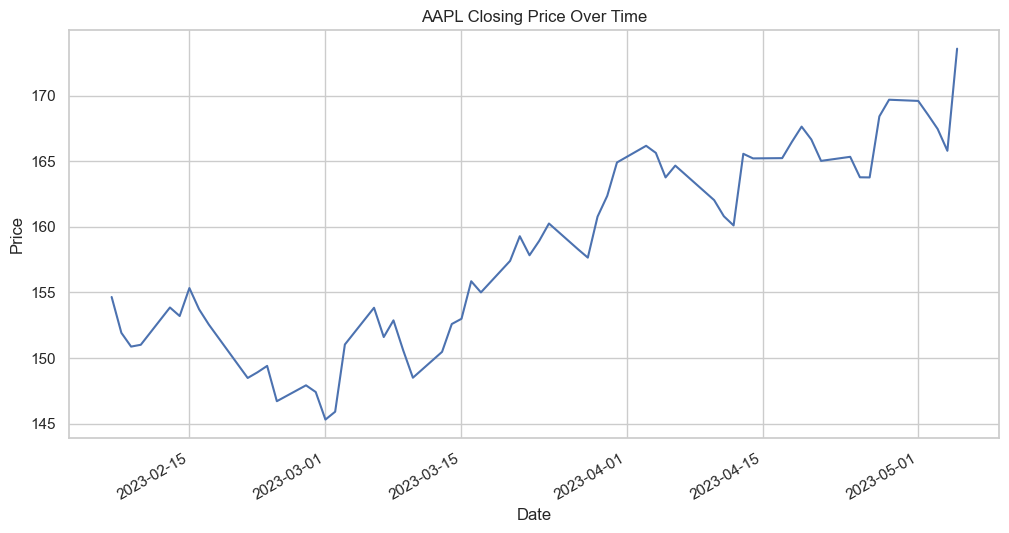

In [9]:
# Closing Price Trend

plt.figure()
price_trend.plot()
plt.title(f"{stock} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

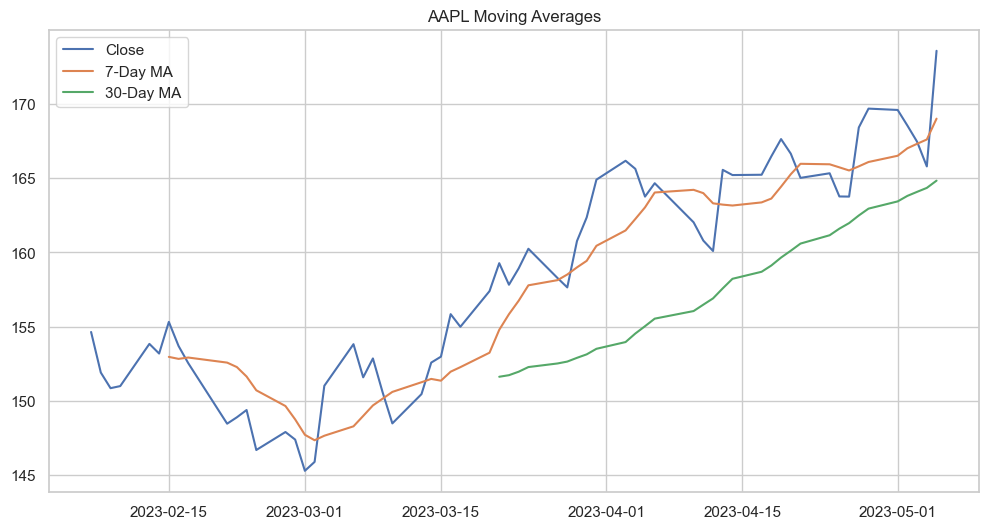

In [10]:
#Moving Averages

plt.figure()
plt.plot(stock_df['Date'], stock_df['Close'], label='Close')
plt.plot(stock_df['Date'], stock_df['MA_7'], label='7-Day MA')
plt.plot(stock_df['Date'], stock_df['MA_30'], label='30-Day MA')
plt.legend()
plt.title(f"{stock} Moving Averages")
plt.show()

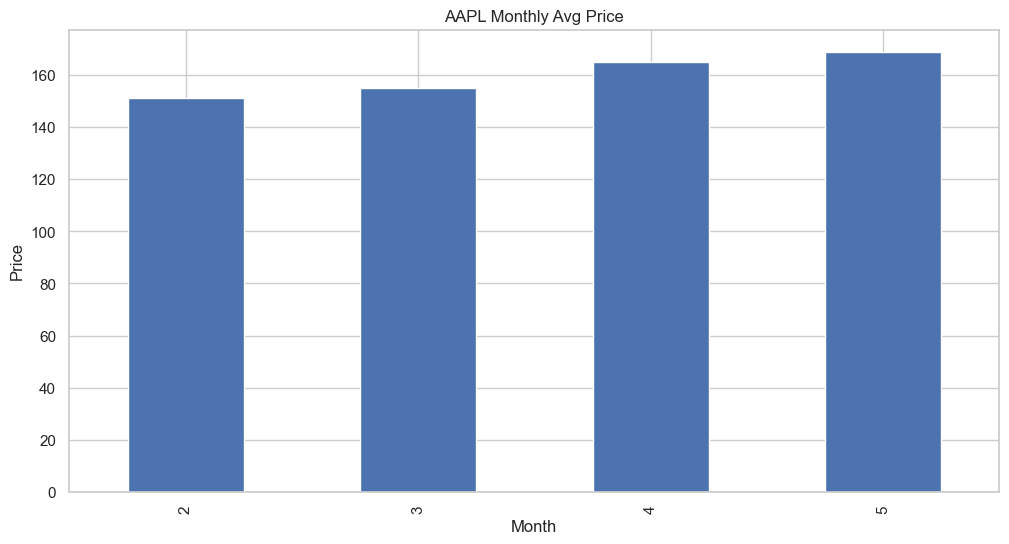

In [11]:
# Monthly Trend

plt.figure()
monthly_avg.plot(kind='bar')
plt.title(f"{stock} Monthly Avg Price")
plt.xlabel("Month")
plt.ylabel("Price")
plt.show()


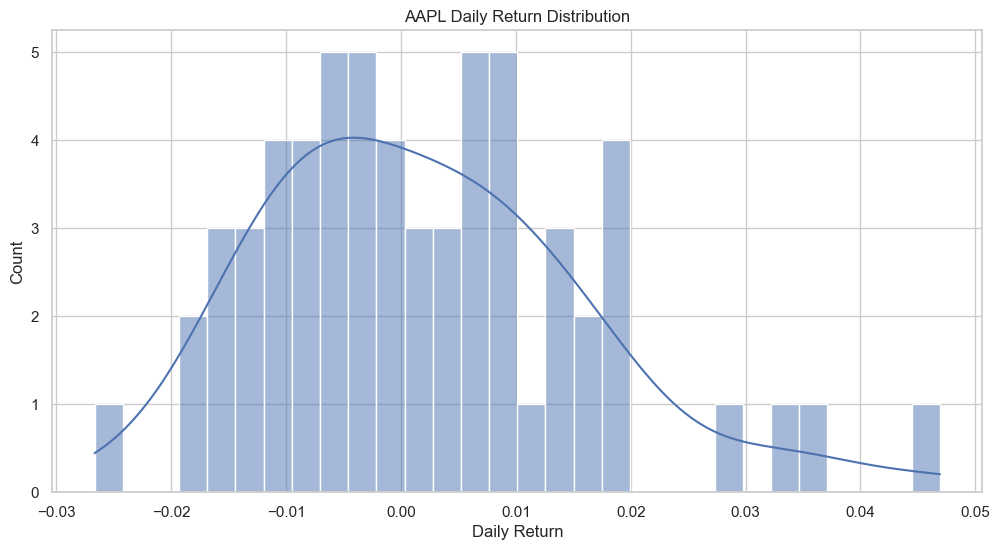

In [12]:
#Daily Return Distribution

plt.figure()
sns.histplot(stock_df['Daily Return'].dropna(), bins=30, kde=True)
plt.title(f"{stock} Daily Return Distribution")
plt.show()

In [13]:
#STATISTICAL ANALYSIS

print("\nStatistical Analysis:")

print("Mean Price:", stock_df['Close'].mean())
print("Median Price:", stock_df['Close'].median())
print("Std Deviation:", stock_df['Close'].std())

print("\nCorrelation Matrix:")
print(stock_df.corr(numeric_only=True))


Statistical Analysis:
Mean Price: 158.24064488564767
Median Price: 158.05500030517578
Std Deviation: 7.360485288670257

Correlation Matrix:
                  Open      High       Low     Close  Adj Close    Volume  \
Open          1.000000  0.986165  0.992285  0.972388   0.972268 -0.137920   
High          0.986165  1.000000  0.992529  0.989163   0.988973 -0.042706   
Low           0.992285  0.992529  1.000000  0.988408   0.988441 -0.112138   
Close         0.972388  0.989163  0.988408  1.000000   0.999977 -0.056305   
Adj Close     0.972268  0.988973  0.988441  0.999977   1.000000 -0.057066   
Volume       -0.137920 -0.042706 -0.112138 -0.056305  -0.057066  1.000000   
Daily Return  0.080311  0.186761  0.153937  0.257376   0.258171  0.402774   
MA_7          0.949805  0.941564  0.950304  0.941130   0.941130 -0.190778   
MA_30         0.843217  0.845886  0.847343  0.802217   0.802217  0.141996   
Month         0.855136  0.853635  0.850272  0.840372   0.841418 -0.050283   
Year        